<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nelson/asah_fetch_a25_cs328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

from yellowbrick.cluster import KElbowVisualizer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.graph_objs as go

import os
import shutil
import joblib

# **Data Loading**


In [2]:
from google.colab import files
files.upload()
print("API Key Received")

Saving kaggle.json to kaggle (9).json
API Key Received


In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Download dataset dari Kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d viridianachow/online-retail-uci-dataset
!kaggle datasets download -d mashlyn/online-retail-ii-uci
!unzip "online-retail-uci-dataset.zip"
!unzip online-retail-ii-uci.zip

Dataset URL: https://www.kaggle.com/datasets/viridianachow/online-retail-uci-dataset
License(s): unknown
online-retail-uci-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
online-retail-ii-uci.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  online-retail-uci-dataset.zip
replace Online Retail.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Online Retail.csv       
Archive:  online-retail-ii-uci.zip
replace online_retail_II.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: online_retail_II.csv    


In [4]:
# Membuat path directory
df_1 = pd.read_csv('Online Retail.csv')
df_2 = pd.read_csv('online_retail_II.csv')

In [5]:
df_2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## **Exploratory Data Analysis (EDA)**

In [6]:
# Menyamakan nama kolom agar kedua DataFrame dapat digabung
column_names = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
df_1.columns = df_2.columns = column_names

In [7]:
# Gabung menjadi 1 DataFrame
df = pd.concat([df_1, df_2])

df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


In [9]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
count,1609280,1609280,1603444,1.609280e+06,1609280,1.609280e+06,1.231193e+06,1609280
unique,53628,5305,5698,NaN,70895,NaN,NaN,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,2228,8142,8287,NaN,1350,NaN,NaN,1476808
mean,NaN,NaN,NaN,9.808698e+00,NaN,4.636499e+00,1.531243e+04,NaN
std,NaN,NaN,NaN,1.892047e+02,NaN,1.152285e+02,1.702901e+03,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,1.234600e+04,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,1.396900e+04,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,1.522000e+04,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.130000e+00,1.679500e+04,NaN


In [10]:
df_fixed = df.copy()
df_fixed = df_fixed.drop(['Description'], axis=1)

df_fixed = df_fixed[~df_fixed['Invoice'].astype(str).str.startswith('C', na=False)]

numeric_cols = ['Invoice', 'StockCode', 'Quantity', 'Price', 'CustomerID']

for col in numeric_cols:
    df_fixed[col] = pd.to_numeric(df_fixed[col], errors='coerce')

df_fixed['InvoiceDate'] = pd.to_datetime(df_fixed['InvoiceDate'], format='mixed')

In [11]:
df_fixed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1580498 entries, 0 to 1067370
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1580489 non-null  float64       
 1   StockCode    1395300 non-null  float64       
 2   Quantity     1580498 non-null  int64         
 3   InvoiceDate  1580498 non-null  datetime64[ns]
 4   Price        1580498 non-null  float64       
 5   CustomerID   1203544 non-null  float64       
 6   Country      1580498 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 96.5+ MB


In [12]:
df_lencoder = df_fixed.copy()

le = LabelEncoder()
df_lencoder['Country'] = le.fit_transform(df_lencoder['Country'])

In [13]:
df_lencoder.describe(include='all')

,Invoice,StockCode,Quantity,InvoiceDate,Price,CustomerID,Country
count,1.580489e+06,1.395300e+06,1.580498e+06,1580498,1.580498e+06,1.203544e+06,1.580498e+06
mean,5.451426e+05,2.790092e+04,1.047360e+01,2011-03-05 18:31:11.666703616,3.883084e+00,1.531944e+04,3.813457e+01
min,4.894340e+05,1.000200e+04,-9.600000e+03,2009-12-01 07:45:00,-5.359436e+04,1.234600e+04,0.000000e+00
25%,5.280570e+05,2.178700e+04,1.000000e+00,2010-10-20 11:58:00,1.250000e+00,1.397500e+04,4.000000e+01
50%,5.483730e+05,2.242300e+04,3.000000e+00,2011-03-30 16:34:00,2.100000e+00,1.523800e+04,4.000000e+01
75%,5.667350e+05,2.298700e+04,1.000000e+01,2011-09-14 14:19:00,4.130000e+00,1.680100e+04,4.000000e+01
max,5.815870e+05,9.020800e+04,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,1.828700e+04,4.200000e+01
std,2.537267e+04,1.730115e+04,1.439335e+02,NaN,8.056432e+01,1.702300e+03,6.831865e+00


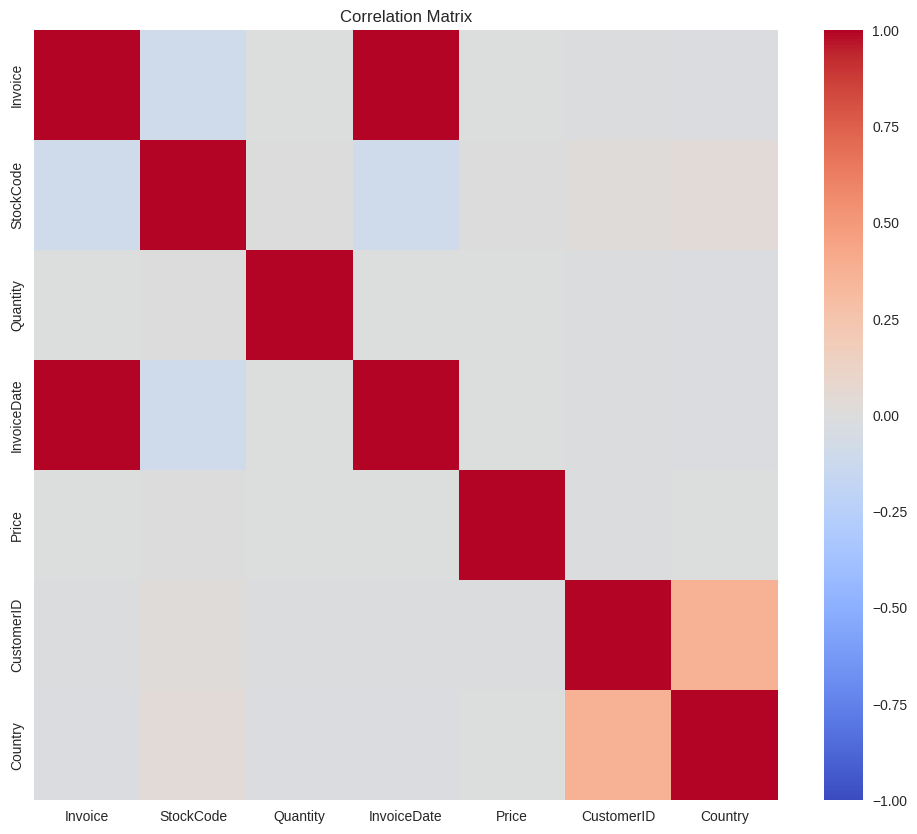

In [14]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_lencoder.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

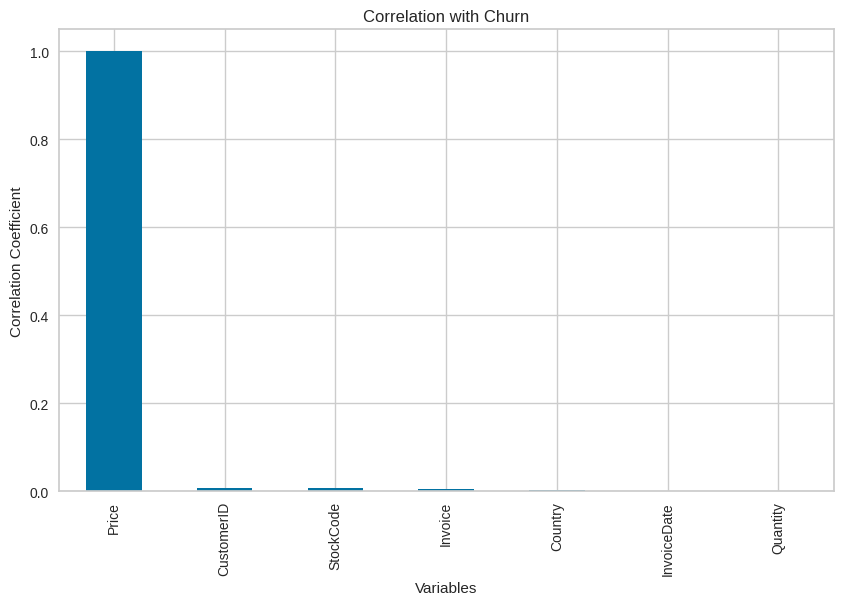

In [15]:
target_corr = df_lencoder.corr()['Price']

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with Churn')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

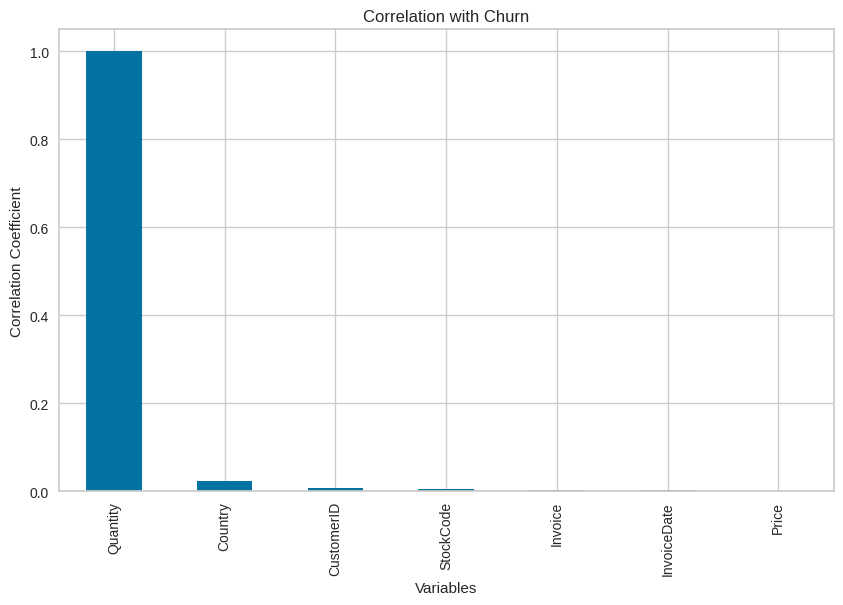

In [16]:
target_corr = df_lencoder.corr()['Quantity']

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with Churn')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

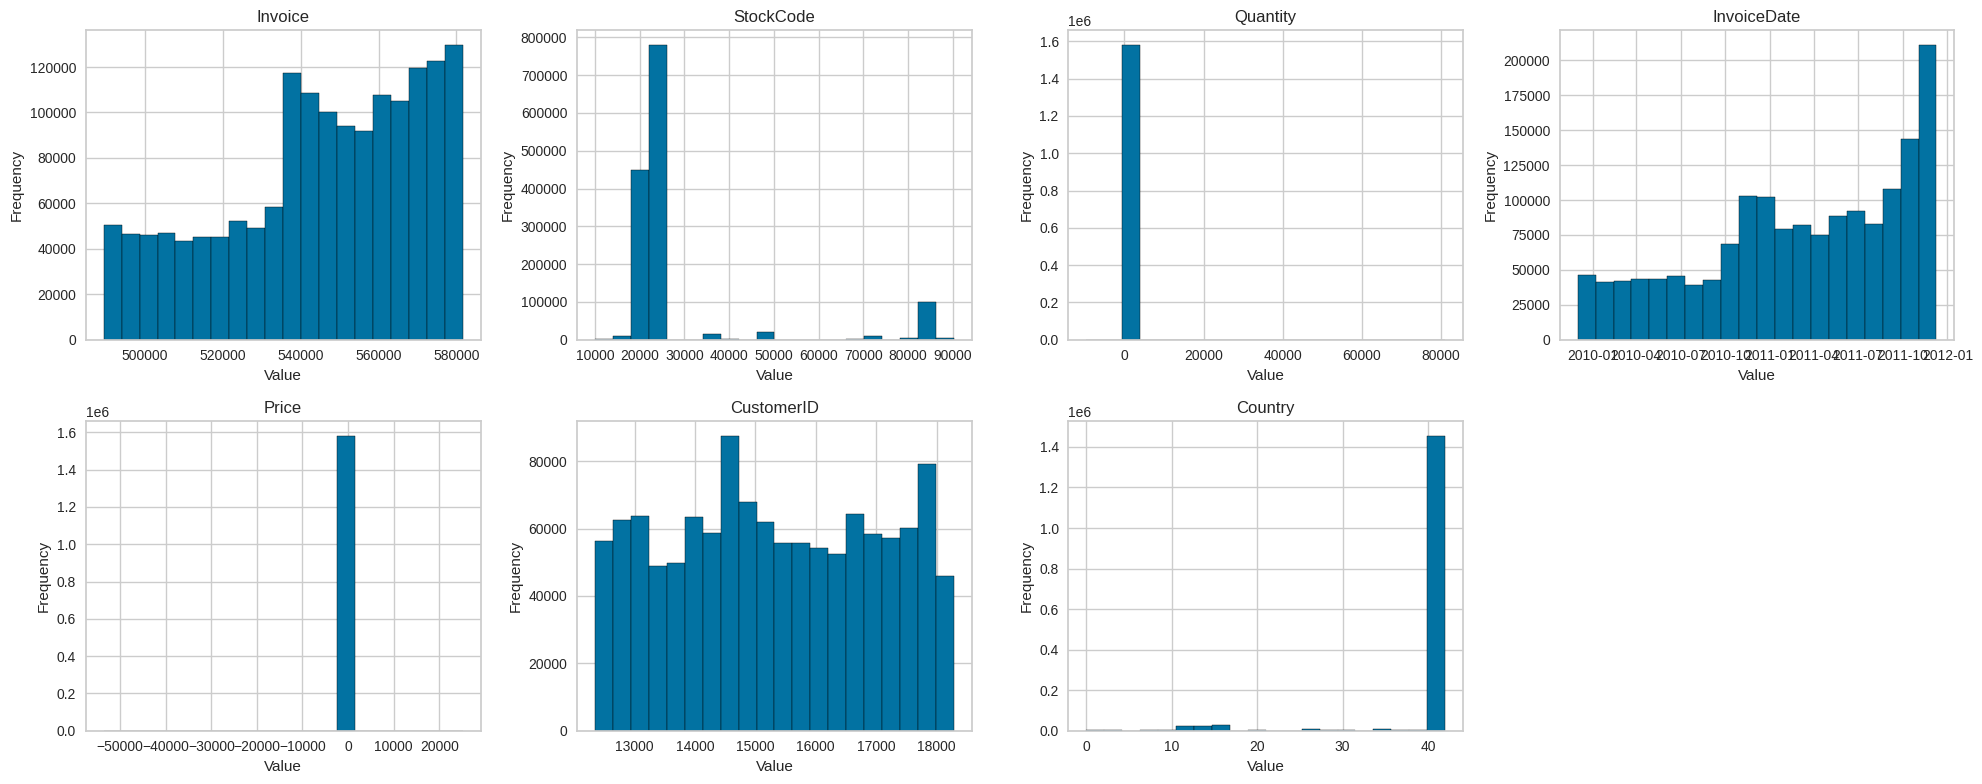

In [17]:
num_vars = df_lencoder.shape[1]

n_cols = 4
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

axes = axes.flatten()

for i, column in enumerate(df_lencoder.columns):
    df_lencoder[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Preprocessing**

In [18]:
df = df.drop(['Description'], axis=1)

df = df[~df['Invoice'].astype(str).str.startswith('C', na=False)]

numeric_cols = ['Invoice', 'StockCode', 'Quantity', 'Price', 'CustomerID']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

In [19]:
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1580498 entries, 0 to 1067370
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1580489 non-null  float64       
 1   StockCode    1395300 non-null  float64       
 2   Quantity     1580498 non-null  int64         
 3   InvoiceDate  1580498 non-null  datetime64[ns]
 4   Price        1580498 non-null  float64       
 5   CustomerID   1203544 non-null  float64       
 6   Country      1580498 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 96.5 MB


In [21]:
df.duplicated().sum()

np.int64(599300)

In [22]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.dropna()

In [24]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Quantity,0
InvoiceDate,0
Price,0
CustomerID,0
Country,0


In [25]:
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [26]:
feature_cols = ['Quantity', 'Price', 'InvoiceDate']

Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

condition = ~((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[condition]

df.describe(include="all")

,Invoice,StockCode,Quantity,InvoiceDate,Price,CustomerID,Country
count,586934.000000,586934.000000,586934.000000,586934,586934.000000,586934.000000,586934.000000
mean,538535.502930,27885.707722,7.480296,2011-01-12 04:23:33.243533312,2.246248,15338.597967,37.825721
min,489434.000000,10002.000000,1.000000,2009-12-01 07:45:00,0.060000,12346.000000,0.000000
25%,516162.000000,21706.000000,2.000000,2010-07-18 12:07:00,1.250000,13985.000000,40.000000
50%,538086.000000,22367.000000,6.000000,2010-12-09 14:44:00,1.650000,15298.000000,40.000000
75%,563288.000000,22920.000000,12.000000,2011-08-15 12:53:00,2.950000,16805.000000,40.000000
max,581587.000000,90208.000000,27.000000,2011-12-09 12:50:00,7.500000,18287.000000,42.000000
std,26845.702813,17371.480984,6.707556,NaN,1.600226,1694.930727,7.341525


In [27]:
df['Sales'] = df['Quantity'] * df['Price']
tgl_pengambilan = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df

,Invoice,StockCode,Quantity,InvoiceDate,Price,CustomerID,Country,Sales
1,536365.0,71053.0,6,2010-12-01 08:26:00,3.39,17850.0,40,20.34
6,536365.0,21730.0,6,2010-12-01 08:26:00,4.25,17850.0,40,25.50
7,536366.0,22633.0,6,2010-12-01 08:28:00,1.85,17850.0,40,11.10
8,536366.0,22632.0,6,2010-12-01 08:28:00,1.85,17850.0,40,11.10
10,536367.0,22745.0,6,2010-12-01 08:34:00,2.10,13047.0,40,12.60
...,...,...,...,...,...,...,...,...
502931,536364.0,21165.0,12,2010-11-30 19:35:00,1.69,14441.0,40,20.28
502932,536364.0,85152.0,12,2010-11-30 19:35:00,2.10,14441.0,40,25.20
502933,536364.0,21175.0,12,2010-11-30 19:35:00,2.10,14441.0,40,25.20
502935,536364.0,21098.0,12,2010-11-30 19:35:00,1.25,14441.0,40,15.00


In [28]:
df_rfm = df.groupby('CustomerID').agg(
  Recency=('InvoiceDate', lambda x: (tgl_pengambilan - x.max()).days),
  Frequency=('Invoice', 'nunique'),
  Monetary=('Sales', 'sum')
).reset_index()

df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,529,2,144.02
1,12347.0,2,8,3315.56
2,12348.0,249,4,311.36
3,12349.0,19,3,2455.16
4,12350.0,310,1,258.00
...,...,...,...,...
5643,18283.0,4,22,2330.08
5644,18284.0,432,1,266.48
5645,18285.0,661,1,93.20
5646,18286.0,477,2,828.29


In [29]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5648.000000,5648.000000,5648.000000,5648.000000
mean,15319.329851,200.614908,5.825602,1349.119359
std,1715.437653,208.394096,11.336672,3286.652786
min,12346.000000,1.000000,1.000000,1.250000
25%,13837.750000,26.000000,1.000000,213.650000
50%,15321.500000,96.000000,3.000000,541.325000
75%,16803.250000,379.000000,6.000000,1376.157500
max,18287.000000,738.000000,365.000000,154507.640000


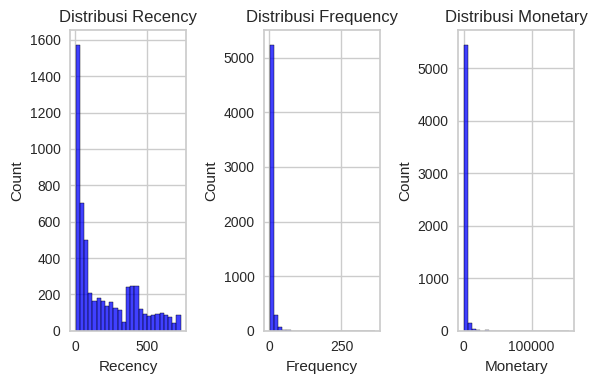

In [30]:
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

In [31]:
df_rfm_log = df_rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)
df_rfm_log.head()

,Recency,Frequency,Monetary
0,6.272877,1.098612,4.976872
1,1.098612,2.197225,8.106683
2,5.521461,1.609438,5.744156
3,2.995732,1.386294,7.806354
4,5.739793,0.693147,5.556828


In [32]:
scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(df_rfm_log)

df_rfm_scaled = pd.DataFrame(rfm_scaled, columns=df_rfm_log.columns, index=df_rfm_log.index)

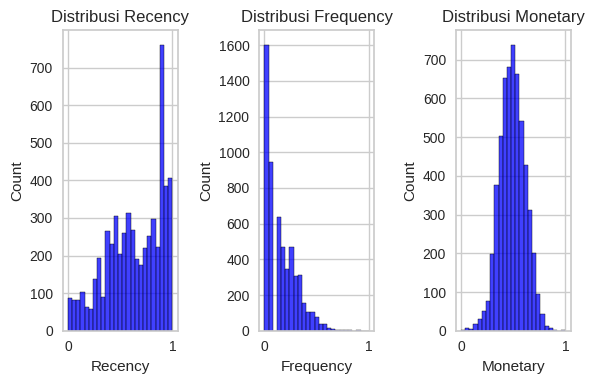

In [33]:
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm_scaled[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# **Clustering**

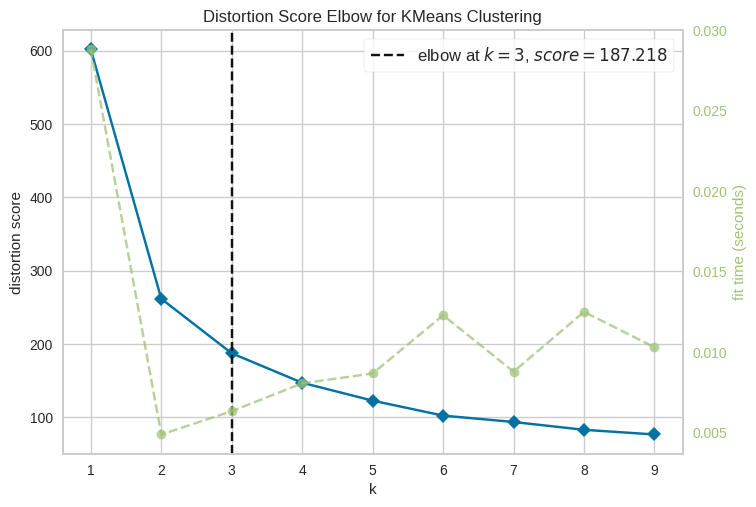

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [34]:
kmeans = KMeans()
Visualizer = KElbowVisualizer(kmeans, k=(1,10))
Visualizer.fit(df_rfm_scaled)
Visualizer.show()

In [35]:
X_model = df_rfm_scaled.values

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_model)
labels = kmeans.labels_
k = 3

df_rfm['Cluster'] = labels

def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mean_frequency = cluster_data[:, 1].mean()
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Rata-rata (mean) Frequency: {mean_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

analyze_clusters(X_model, labels, k)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: 0.5365643821663366
Rata-rata (mean) Frequency: 0.16192569701731682
Rata-rata (mean) Monetary: 0.5066418029185479

Cluster 2:
Rata-rata (mean) Recency: 0.8787314597461946
Rata-rata (mean) Frequency: 0.07195309502882556
Rata-rata (mean) Monetary: 0.42394865758476613

Cluster 3:
Rata-rata (mean) Recency: 0.2591962413563098
Rata-rata (mean) Frequency: 0.3526655165905071
Rata-rata (mean) Monetary: 0.6276787010791619


In [36]:
score = silhouette_score(df_rfm_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.40227585637981833


In [37]:
visual_3d = go.Scatter3d(
    x= df_rfm['Recency'],
    y= df_rfm['Frequency'],
    z= df_rfm['Monetary'],
    mode='markers',
     marker=dict(
        color = df_rfm['Cluster'],
        size= 20,
        line=dict(
            color= df_rfm['Cluster'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")